In [ ]:
pip install numpy scipy torch wfdb matplotlib

In [ ]:
!pip install mne


# Imagery–Execution Neural Coupling as a Disability-Relevant Capacity

~ How consistently can the brain express the same motor intention across imagined and executed conditions — and can we learn and measure that consistency robustly?” ~

Most existing works do ONE of these:

Compare MI vs ME statistically

Transfer learning from ME → MI

Improve MI classification accuracy

Analyze ERD/ERS differences

❌ They do not:

Define a learned, subject-specific coupling metric

Optimize that metric explicitly during training

Test coupling robustness under task shift (fist → feet)

# The Methodology (This is the heart — read carefully)

Representation-first, not classification-first

Instead of “EEG → class”, you learn a latent motor-intention space:

MI and ME are treated as two physiological realizations of the same hidden intention

The intention space must be:

subject-consistent

condition-invariant (MI vs ME)

task-generalizable (fist → feet)

This already elevates the work above typical BCI papers.

Architecture: Coupling-Aware Dual Encoder (CADE)
High-level structure

Two encoders:

EMI
E
MI
	​

: Motor imagery EEG

EME
E
ME
	​

: Motor execution EEG

Partial weight sharing

early layers shared (basic rhythms)

later layers condition-specific (MI vs ME dynamics)

Why this is novel:

Not Siamese copying

Not fully separate

Explicitly models shared vs condition-specific neurodynamics

This kind of architectural decision is rare in disability EEG papers.

# Imagery–Execution Coupling (IECI) — Full Pipeline (PhysioNet EEGMMIDB)
Train: Left/Right Fist (MI+ME)  
OOD Eval: Both Fists / Both Feet (unseen task)  
Subjects: First 10 (development), scalable to full dataset


In [3]:
import os
import re
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import mne

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [5]:
# ----------------------------
# CONFIG (edit only here)
# ----------------------------



DATA_ROOT = os.path.expanduser("C:\\Users\\user\\Documents\\GitHub\\Disability_Project\\datasets\\EEG_Motor_Movement_Imagery_Dataset")
SUBJECT_LIMIT = None          # development; set None for full dataset
SEED = 123

# windowing
T_PRE = 0.0                 # seconds relative to event onset
T_POST = 4.0                # seconds window length
DROP_T0 = True              # ignore rest events

# preprocessing
BANDPASS = (0.5, 45.0)
NOTCH = 60.0                # set 50.0 if your environment uses 50Hz

# training
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
BATCH_SIZE = 64
EPOCHS = 15
LR = 3e-4
WEIGHT_DECAY = 1e-4


# losses case 0: all enabled
LAMBDA_CCL = 1.0
LAMBDA_TF  = 0.3
LAMBDA_REG = 0.3
LAMBDA_CLS = 0.2  
       


# # losses case 1: Ablation:without TF loss
# LAMBDA_CCL = 1.0
# LAMBDA_TF  = 0.0
# LAMBDA_REG = 0.3
# LAMBDA_CLS = 0.2          



# # losses case 2: Ablation:without Reg loss
# LAMBDA_CCL = 1.0
# LAMBDA_TF  = 0.3
# LAMBDA_REG = 0.0
# LAMBDA_CLS = 0.2  


print(LAMBDA_CCL, LAMBDA_TF, LAMBDA_REG, LAMBDA_CLS) 




TAU = 0.07                   # temperature for contrastive
TF_NFFT = 256                # STFT n_fft (keep <= window length)
TF_HOP  = 64                 # hop length
EPS = 1e-8

# train on LR_FIST only; OOD eval on BF_BFET
TRAIN_TASK = "LR_FIST"
OOD_TASK = "BF_BFET"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)

FS_EEG = 160.0            # EEGMMIDB sampling rate (normally 160)
DOWNSAMPLE_FACTOR = 4     # your shared encoder downsamples time by 2 then 2
FS_FEAT = FS_EEG / DOWNSAMPLE_FACTOR

MU_BETA_LO = 8.0
MU_BETA_HI = 30.0

print("FS_FEAT:", FS_FEAT)



Using device: cuda
1.0 0.3 0.3 0.2
DEVICE: cuda
DATA_ROOT: C:\Users\user\Documents\GitHub\Disability_Project\datasets\EEG_Motor_Movement_Imagery_Dataset
FS_FEAT: 40.0


## 2) Scan EEGMMIDB (nested folders S001/S001R03.edf)
We map runs to:
- LR_FIST: left/right fist
- BF_BFET: both fists / both feet
and conditions:
- MI or ME


In [6]:
RUN_MAP = {
    1: ("baseline", "EO"),
    2: ("baseline", "EC"),
    3: ("ME", "LR_FIST"),
    4: ("MI", "LR_FIST"),
    5: ("ME", "BF_BFET"),
    6: ("MI", "BF_BFET"),
    7: ("ME", "LR_FIST"),
    8: ("MI", "LR_FIST"),
    9: ("ME", "BF_BFET"),
    10: ("MI", "BF_BFET"),
    11: ("ME", "LR_FIST"),
    12: ("MI", "LR_FIST"),
    13: ("ME", "BF_BFET"),
    14: ("MI", "BF_BFET"),
}

@dataclass
class RecordInfo:
    subject: int
    run: int
    path: str
    condition: str  # "MI", "ME", "baseline"
    task: str       # "LR_FIST", "BF_BFET", "EO", "EC"

def scan_eegmmidb_nested(root_dir: str, subjects_limit: Optional[int]=None) -> List[RecordInfo]:
    subj_dirs = sorted([d for d in os.listdir(root_dir) if re.match(r"^S\d{3}$", d)])
    if subjects_limit is not None:
        subj_dirs = subj_dirs[:subjects_limit]

    pat = re.compile(r"S(\d{3})R(\d{2})\.edf$")
    records = []

    for sd in subj_dirs:
        subj_id = int(sd[1:])
        subj_path = os.path.join(root_dir, sd)
        for fn in os.listdir(subj_path):
            m = pat.match(fn)
            if not m:
                continue
            run = int(m.group(2))
            if run not in RUN_MAP:
                continue
            cond, task = RUN_MAP[run]
            records.append(RecordInfo(subj_id, run, os.path.join(subj_path, fn), cond, task))

    records.sort(key=lambda x: (x.subject, x.run))
    return records

records = scan_eegmmidb_nested(DATA_ROOT, SUBJECT_LIMIT)
print("EDF count:", len(records))
print("Subjects:", sorted(set(r.subject for r in records))[:20], "...")
print("Example:", records[0])


EDF count: 1526
Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...
Example: RecordInfo(subject=1, run=1, path='C:\\Users\\user\\Documents\\GitHub\\Disability_Project\\datasets\\EEG_Motor_Movement_Imagery_Dataset\\S001\\S001R01.edf', condition='baseline', task='EO')


## 3) EDF loading + filtering + annotations (T0/T1/T2) + window extraction
We use MNE to read EDF, apply bandpass + notch, and extract annotation events.
Then we cut fixed windows around T1/T2 onsets.


In [7]:
EVENT_CODE_MAP = {"T0": 0, "T1": 1, "T2": 2}

def load_edf_and_events(edf_path: str):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.rename_channels(lambda s: s.strip().upper())
    fs = float(raw.info["sfreq"])

    raw.filter(BANDPASS[0], BANDPASS[1], fir_design="firwin", verbose=False)
    raw.notch_filter([NOTCH], verbose=False)

    events = []
    for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
        d = desc.strip()
        if d in EVENT_CODE_MAP:
            sample = int(round(onset * fs))
            events.append((sample, EVENT_CODE_MAP[d]))

    X = raw.get_data().astype(np.float32)  # (C,T)
    return X, fs, events

def make_event_windows(X: np.ndarray, fs: float, events: List[Tuple[int,int]],
                       t_pre: float, t_post: float, drop_t0: bool=True):
    C, T = X.shape
    s_pre = int(round(t_pre * fs))
    s_post = int(round(t_post * fs))
    L = s_post - s_pre
    assert L > 0

    Ws, ys = [], []
    for onset, code in events:
        if drop_t0 and code == 0:
            continue
        start = onset + s_pre
        end = onset + s_post
        if start < 0 or end > T:
            continue
        Ws.append(X[:, start:end])
        ys.append(code)

    if len(Ws) == 0:
        return np.zeros((0, C, L), np.float32), np.zeros((0,), np.int64)

    return np.stack(Ws).astype(np.float32), np.array(ys, dtype=np.int64)

# quick sanity on one EDF
rec0 = [r for r in records if (r.task == TRAIN_TASK and r.condition in ("MI","ME"))][0]
X0, fs0, ev0 = load_edf_and_events(rec0.path)
W0, y0 = make_event_windows(X0, fs0, ev0, T_PRE, T_POST, drop_t0=True)

print("One record:", rec0.path)
print("X:", X0.shape, "fs:", fs0, "events:", len(ev0))
print("Windows:", W0.shape, "labels unique:", sorted(set(y0.tolist())))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
One record: C:\Users\user\Documents\GitHub\Disability_Project\datasets\EEG_Motor_Movement_Imagery_Dataset\S001\S001R03.edf
X: (64, 20000) fs: 160.0 events: 30
Windows: (15, 64, 640) labels unique: [1, 2]


## 4) Build true paired MI–ME windows (same subject, same label)
We pair windows by label (T1/T2) and by occurrence order.
This creates training samples: (MI_window, ME_window, label, subject).


In [8]:
def extract_windows_for_record(rec: RecordInfo):
    X, fs, events = load_edf_and_events(rec.path)
    W, y = make_event_windows(X, fs, events, T_PRE, T_POST, drop_t0=DROP_T0)
    return W, y, fs

def build_pairs(records: List[RecordInfo], task: str) -> List[Dict]:
    """
    task: "LR_FIST" or "BF_BFET"
    """
    by_subj: Dict[int, List[RecordInfo]] = {}
    for r in records:
        if r.task != task or r.condition not in ("MI","ME"):
            continue
        by_subj.setdefault(r.subject, []).append(r)

    paired = []
    for s, recs in tqdm(by_subj.items(), desc=f"Pairing task={task}"):
        mi_recs = sorted([r for r in recs if r.condition == "MI"], key=lambda x: x.run)
        me_recs = sorted([r for r in recs if r.condition == "ME"], key=lambda x: x.run)
        if len(mi_recs) == 0 or len(me_recs) == 0:
            continue

        mi_by_label = {1: [], 2: []}
        me_by_label = {1: [], 2: []}
        fs_ref = None

        for r in mi_recs:
            W, y, fs = extract_windows_for_record(r)
            fs_ref = fs_ref or fs
            for w, lab in zip(W, y):
                if lab in (1,2):
                    mi_by_label[int(lab)].append(w)

        for r in me_recs:
            W, y, fs = extract_windows_for_record(r)
            fs_ref = fs_ref or fs
            for w, lab in zip(W, y):
                if lab in (1,2):
                    me_by_label[int(lab)].append(w)

        for lab in (1,2):
            n = min(len(mi_by_label[lab]), len(me_by_label[lab]))
            for k in range(n):
                paired.append({
                    "subject": s,
                    "label": lab,       # 1 or 2
                    "mi": mi_by_label[lab][k],
                    "me": me_by_label[lab][k],
                    "task": task,
                })

    return paired

paired_train = build_pairs(records, TRAIN_TASK)
print("Paired TRAIN_TASK samples:", len(paired_train))

p = paired_train[0]
print("Example subject:", p["subject"], "label:", p["label"], "mi:", p["mi"].shape, "me:", p["me"].shape)
print("Mean |MI-ME|:", float(np.mean(np.abs(p["mi"] - p["me"]))))


Pairing task=LR_FIST:   0%|          | 0/109 [00:00<?, ?it/s]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=LR_FIST:   1%|          | 1/109 [00:01<01:50,  1.02s/it]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=LR_FIST:   2%|▏         | 2/109 [00:02<01:46,  1.00it/s]

...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=LR_FIST:  99%|█████████▉| 108/109 [01:44<00:00,  1.02it/s]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=LR_FIST: 100%|██████████| 109/109 [01:45<00:00,  1.03it/s]

Paired TRAIN_TASK samples: 4825
Example subject: 1 label: 1 mi: (64, 640) me: (64, 640)
Mean |MI-ME|: 4.2604027839843184e-05


## 5) Subject split (train/val/test) — no leakage
We split subjects (not windows) to avoid leakage.


In [9]:
subjects = sorted(set([d["subject"] for d in paired_train]))
print("Subjects with paired data:", subjects)

random.shuffle(subjects)
n = len(subjects)
n_train = max(1, int(0.7*n))
n_val   = max(1, int(0.15*n))
train_subj = set(subjects[:n_train])
val_subj   = set(subjects[n_train:n_train+n_val])
test_subj  = set(subjects[n_train+n_val:])

print("Train subjects:", sorted(train_subj))
print("Val subjects:", sorted(val_subj))
print("Test subjects:", sorted(test_subj))

def filter_by_subject(paired_list, subj_set):
    return [d for d in paired_list if d["subject"] in subj_set]

train_list = filter_by_subject(paired_train, train_subj)
val_list   = filter_by_subject(paired_train, val_subj)
test_list  = filter_by_subject(paired_train, test_subj)

print("Train/Val/Test samples:", len(train_list), len(val_list), len(test_list))


Subjects with paired data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
Train subjects: [2, 3, 4, 8, 10, 11, 13, 15, 16, 17, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 36, 37, 38, 39, 40, 42, 45, 46, 47, 48, 50, 51, 52, 54, 55, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 91, 92, 93, 94, 96, 100, 102, 104, 105]
Val subjects: [1, 6, 9, 32, 41, 56, 58, 77, 87, 90, 95, 98, 101, 103, 106, 107]
Test subjects: [5, 7, 12, 14, 18, 21, 35, 43, 44, 49, 53, 69, 72, 97, 99, 108, 109]
Train/Val/Test samples: 3372 702 751


## 6) Torch Dataset
We apply per-window channel-wise z-score normalization (stable, common in EEG DL).


In [11]:
def zscore_per_channel(x: torch.Tensor, eps=1e-6):
    # x: (C,L)
    mu = x.mean(dim=1, keepdim=True)
    sd = x.std(dim=1, keepdim=True)
    return (x - mu) / (sd + eps)

class PairedEEGDataset(Dataset):
    def __init__(self, items: List[Dict], normalize=True):
        self.items = items
        self.normalize = normalize

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        d = self.items[idx]
        mi = torch.from_numpy(d["mi"]).float()  # (C,L)
        me = torch.from_numpy(d["me"]).float()  # (C,L)
        y  = int(d["label"]) - 1               # map {1,2} -> {0,1}
        s  = int(d["subject"])

        if self.normalize:
            mi = zscore_per_channel(mi)
            me = zscore_per_channel(me)

        return mi, me, torch.tensor(y, dtype=torch.long), torch.tensor(s, dtype=torch.long)

train_ds = PairedEEGDataset(train_list, normalize=True)
val_ds   = PairedEEGDataset(val_list, normalize=True)
test_ds  = PairedEEGDataset(test_list, normalize=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

#next(iter(train_loader))[0].shape


## 7) CADE Model (Coupling-Aware Dual Encoder)
- Shared stem (learn common rhythms)
- Separate MI / ME heads
- Outputs:
  - embedding z (normalized)
  - optional temporal features for TF-loss
  - optional classifier logits


In [12]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k=7, s=1, p=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm1d(cout),
            nn.GELU()
        )
    def forward(self, x):
        return self.net(x)

class CADEEncoder(nn.Module):
    def __init__(self, C=64, emb=256, mid=128):
        super().__init__()
        # shared: process channels as input features across time
        self.shared = nn.Sequential(
            ConvBlock(C, mid, k=7, s=1, p=3),
            ConvBlock(mid, mid, k=7, s=2, p=3),   # downsample time
            ConvBlock(mid, mid, k=7, s=2, p=3),
        )

        # condition-specific heads
        self.mi_head = nn.Sequential(
            ConvBlock(mid, mid, k=5, s=1, p=2),
            ConvBlock(mid, mid, k=5, s=1, p=2),
        )
        self.me_head = nn.Sequential(
            ConvBlock(mid, mid, k=5, s=1, p=2),
            ConvBlock(mid, mid, k=5, s=1, p=2),
        )

        # pooling to embedding
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Linear(mid, emb)

        # optional classifier
        self.cls = nn.Linear(emb, 2)

    def forward_branch(self, x, branch="MI"):
        """
        x: (B,C,L)
        returns:
          h: (B,mid,T') temporal feature map
          z: (B,emb) embedding
          logits: (B,2)
        """
        h = self.shared(x)
        if branch == "MI":
            h = self.mi_head(h)
        else:
            h = self.me_head(h)

        pooled = self.pool(h).squeeze(-1)  # (B,mid)
        z = self.proj(pooled)              # (B,emb)
        z = F.normalize(z, dim=1)
        logits = self.cls(z)
        return h, z, logits

    def forward(self, mi, me):
        h_mi, z_mi, log_mi = self.forward_branch(mi, "MI")
        h_me, z_me, log_me = self.forward_branch(me, "ME")
        return (h_mi, z_mi, log_mi), (h_me, z_me, log_me)

model = CADEEncoder(C=64, emb=256, mid=128).to(DEVICE)
sum(p.numel() for p in model.parameters()) / 1e6


0.64973

## 8) Losses
- CCL: cross-condition contrastive coupling (InfoNCE)
- TF: time–frequency distribution alignment (differentiable STFT on temporal features)
- REG: coupling regularity across batch repetitions (proxy)
- CLS: auxiliary intention classification (optional)


In [14]:
def info_nce_cross(z_a, z_b, tau=0.07):
    """
    Cross-view InfoNCE:
      positives are diagonal pairs (i<->i)
      negatives are other samples in batch
    z_a, z_b: (B,D) normalized
    """
    B = z_a.shape[0]
    logits = (z_a @ z_b.t()) / tau  # (B,B)
    labels = torch.arange(B, device=z_a.device)
    loss = F.cross_entropy(logits, labels)
    return loss, logits


'''
def tf_distribution(h):
    """
    h: (B, K, T') temporal feature map
    returns P: (B, F, U) normalized distribution over TF bins
    """
    # collapse K channels by mean energy (simple, stable)
    x = h.mean(dim=1)  # (B, T')
    # STFT magnitude
    stft = torch.stft(x, n_fft=TF_NFFT, hop_length=TF_HOP, win_length=TF_NFFT,
                      window=torch.hann_window(TF_NFFT, device=x.device),
                      return_complex=True, center=True)
    mag = torch.abs(stft)  # (B, F, U)
    # log for stability
    A = torch.log(mag + 1e-6)
    # softmax over all bins => distribution
    B, Freq, Time = A.shape
    P = F.softmax(A.reshape(B, -1), dim=1).reshape(B, Freq, Time)
    return P

'''

def tf_distribution_mu_beta(h, fs_feat=FS_FEAT, f_lo=MU_BETA_LO, f_hi=MU_BETA_HI):
    """
    h: (B, K, T') temporal feature map
    returns P: (B, F, U) distribution normalized ONLY over mu/beta bins
    """
    x = h.mean(dim=1)  # (B, T')

    stft = torch.stft(
        x,
        n_fft=TF_NFFT,
        hop_length=TF_HOP,
        win_length=TF_NFFT,
        window=torch.hann_window(TF_NFFT, device=x.device),
        return_complex=True,
        center=True
    )
    mag = torch.abs(stft)             # (B, F, U)
    A = torch.log(mag + 1e-6)         # (B, F, U)

    # Frequency bins for rfft STFT output
    freqs = torch.fft.rfftfreq(TF_NFFT, d=1.0/fs_feat).to(x.device)  # (F,)
    mask_f = (freqs >= f_lo) & (freqs <= f_hi)                       # (F,)
    mask_f = mask_f.view(1, -1, 1)                                   # (1,F,1)

    # Mask out non-mu/beta bins, then softmax over remaining bins only
    A_masked = torch.where(mask_f, A, torch.full_like(A, -1e9))

    B, Freq, Time = A_masked.shape
    P = F.softmax(A_masked.reshape(B, -1), dim=1).reshape(B, Freq, Time)

    # Safety renormalization over masked region (numerical)
    P = P * mask_f.float()
    P = P / (P.sum(dim=(1,2), keepdim=True) + 1e-8)
    return P





def symmetric_kl(P, Q, eps=1e-8):
    # P,Q: (B,F,U), each sums to 1 over F*U
    P = torch.clamp(P, eps, 1.0)
    Q = torch.clamp(Q, eps, 1.0)
    kl1 = (P * (P / Q).log()).sum(dim=(1,2)).mean()
    kl2 = (Q * (Q / P).log()).sum(dim=(1,2)).mean()
    return kl1 + kl2

def coupling_regularity(z_mi, z_me):
    """
    Batch-level proxy for repetition stability:
    encourage consistent alignment scores within batch
    a_i = cos(z_mi_i, z_me_i) (since normalized => dot)
    penalize variance of a_i
    """
    a = (z_mi * z_me).sum(dim=1)  # (B,)
    return a.var(unbiased=False)

def total_loss(batch_out, y, tau=0.07):
    (h_mi, z_mi, log_mi), (h_me, z_me, log_me) = batch_out

    # CCL: both directions
    l1, _ = info_nce_cross(z_mi, z_me, tau=tau)
    l2, _ = info_nce_cross(z_me, z_mi, tau=tau)
    L_ccl = 0.5 * (l1 + l2)

    # TF loss
    # P_mi = tf_distribution(h_mi)
    # P_me = tf_distribution(h_me)
    P_mi = tf_distribution_mu_beta(h_mi)
    P_me = tf_distribution_mu_beta(h_me)


    L_tf = symmetric_kl(P_mi, P_me)

    # REG
    L_reg = coupling_regularity(z_mi, z_me)

    # CLS
    if LAMBDA_CLS > 0.0:
        L_cls = 0.5*(F.cross_entropy(log_mi, y) + F.cross_entropy(log_me, y))
    else:
        L_cls = torch.tensor(0.0, device=y.device)

    L = (LAMBDA_CCL*L_ccl +
         LAMBDA_TF *L_tf  +
         LAMBDA_REG*L_reg +
         LAMBDA_CLS*L_cls)

    return L, {"ccl": L_ccl.detach(), "tf": L_tf.detach(), "reg": L_reg.detach(), "cls": L_cls.detach()}


## 9) Training (real)
We train only on LR_FIST paired MI–ME.


In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def run_epoch(loader, train=True):
    model.train(train)
    tot = 0.0
    logs_sum = {"ccl":0.0, "tf":0.0, "reg":0.0, "cls":0.0}
    n = 0

    for mi, me, y, s in tqdm(loader, leave=False):
        mi = mi.to(DEVICE)  # (B,C,L)
        me = me.to(DEVICE)
        y  = y.to(DEVICE)

        if train:
            optimizer.zero_grad()

        out = model(mi, me)
        loss, logs = total_loss(out, y, tau=TAU)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        bsz = mi.size(0)
        tot += float(loss.item()) * bsz
        for k in logs_sum:
            logs_sum[k] += float(logs[k].item()) * bsz
        n += bsz

    return tot/n, {k: v/n for k,v in logs_sum.items()}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_logs = run_epoch(train_loader, train=True)
    va_loss, va_logs = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch:03d} | train={tr_loss:.4f} val={va_loss:.4f} "
          f"| ccl={tr_logs['ccl']:.3f} tf={tr_logs['tf']:.3f} reg={tr_logs['reg']:.3f} cls={tr_logs['cls']:.3f}")


RuntimeError: stack expects each tensor to be equal size, but got [64, 640] at entry 0 and [64, 512] at entry 28

## 10) IECI computation
IECI(s) = mean cosine similarity between paired MI and ME embeddings for subject s.


In [26]:
@torch.no_grad()
def compute_ieci(paired_items: List[Dict], normalize=True):
    model.eval()
    subj_scores = {}

    for d in tqdm(paired_items, desc="IECI", leave=False):
        mi = torch.from_numpy(d["mi"]).float()
        me = torch.from_numpy(d["me"]).float()
        if normalize:
            mi = zscore_per_channel(mi)
            me = zscore_per_channel(me)

        mi = mi.unsqueeze(0).to(DEVICE)  # (1,C,L)
        me = me.unsqueeze(0).to(DEVICE)

        (h_mi, z_mi, _), (h_me, z_me, _) = model(mi, me)
        sim = float((z_mi * z_me).sum(dim=1).item())  # cosine (normalized)

        s = int(d["subject"])
        subj_scores.setdefault(s, []).append(sim)

    ieci = {s: float(np.mean(v)) for s,v in subj_scores.items()}
    return ieci

ieci_train = compute_ieci(train_list)
ieci_val   = compute_ieci(val_list)
ieci_test  = compute_ieci(test_list)

print("IECI (train) sample:", list(ieci_train.items())[:5])
print("IECI (val) sample:", list(ieci_val.items())[:5])
print("IECI (test) sample:", list(ieci_test.items())[:5])


IECI (train) sample: [(3, 0.5971809700131416), (4, 0.7690445279533212), (6, 0.5795532208542491), (7, 0.48786866201294793), (8, 0.5993737214141421)]
IECI (val) sample: [(2, 0.05700564955671628)]
IECI (test) sample: [(1, 0.35834792049394715), (5, 0.4123120368566624)]


## IECI stability & aggregation (figures + code)

In [27]:
@torch.no_grad()
def compute_similarity_table(paired_items: List[Dict], normalize=True, tag="LR_FIST"):
    model.eval()
    rows = []
    for d in tqdm(paired_items, desc=f"SIM {tag}", leave=False):
        mi = torch.from_numpy(d["mi"]).float()
        me = torch.from_numpy(d["me"]).float()
        if normalize:
            mi = zscore_per_channel(mi)
            me = zscore_per_channel(me)

        mi = mi.unsqueeze(0).to(DEVICE)
        me = me.unsqueeze(0).to(DEVICE)

        (_, z_mi, _), (_, z_me, _) = model(mi, me)
        sim = float((z_mi * z_me).sum(dim=1).item())

        rows.append({
            "subject": int(d["subject"]),
            "label_raw": int(d["label"]),        # 1=T1, 2=T2
            "label": "T1" if int(d["label"])==1 else "T2",
            "task": d.get("task", tag),
            "sim": sim
        })
    return pd.DataFrame(rows)

df_lr = compute_similarity_table(test_list, normalize=True, tag="LR_FIST_test")
df_lr.head(), df_lr.shape

df_ood = compute_similarity_table(ood_test, normalize=True, tag="BF_BFET_test")
df_ood.head(), df_ood.shape



(   subject  label_raw label     task       sim
 0        1          1    T1  BF_BFET  0.502781
 1        1          1    T1  BF_BFET  0.202986
 2        1          1    T1  BF_BFET  0.515848
 3        1          1    T1  BF_BFET  0.531131
 4        1          1    T1  BF_BFET  0.511788,
 (87, 5))

## Subject-level IECI mean/std + label-wise IECI

In [28]:
def summarize_ieci(df: pd.DataFrame):
    # subject-level
    subj = df.groupby("subject")["sim"].agg(["mean","std","count"]).reset_index()
    subj = subj.rename(columns={"mean":"IECI_mean","std":"IECI_std","count":"n_pairs"})

    # subject x label-level
    subj_label = df.groupby(["subject","label"])["sim"].agg(["mean","std","count"]).reset_index()
    subj_label = subj_label.rename(columns={"mean":"IECI_mean","std":"IECI_std","count":"n_pairs"})
    return subj, subj_label

sum_lr, sum_lr_label = summarize_ieci(df_lr)
sum_ood, sum_ood_label = summarize_ieci(df_ood)

print("LR summary:\n", sum_lr)
print("\nOOD summary:\n", sum_ood)


LR summary:
    subject  IECI_mean  IECI_std  n_pairs
0        1   0.358348  0.145654       45
1        5   0.412312  0.131722       43

OOD summary:
    subject  IECI_mean  IECI_std  n_pairs
0        1   0.387510  0.139163       43
1        5   0.305433  0.169387       44


# Paper-grade plots

## Histogram: IECI distributions (LR vs OOD)

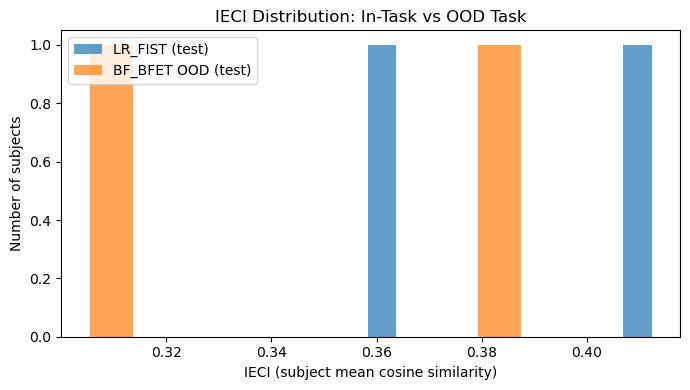

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(sum_lr["IECI_mean"].dropna(), bins=10, alpha=0.7, label="LR_FIST (test)")
plt.hist(sum_ood["IECI_mean"].dropna(), bins=10, alpha=0.7, label="BF_BFET OOD (test)")
plt.xlabel("IECI (subject mean cosine similarity)")
plt.ylabel("Number of subjects")
plt.title("IECI Distribution: In-Task vs OOD Task")
plt.legend()
plt.tight_layout()
plt.show()


## Scatter: LR vs OOD (per subject)

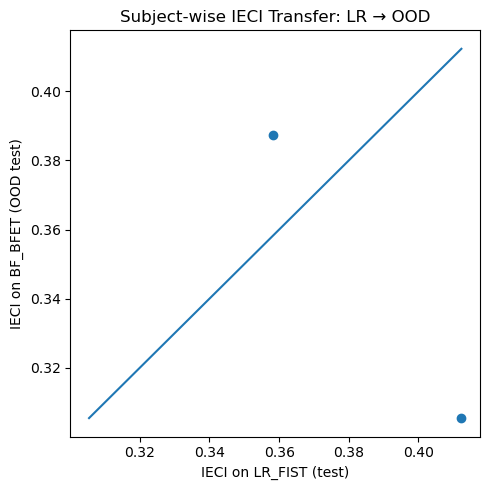

,subject,IECI_mean_LR,IECI_mean_OOD
0,1,0.358348,0.387510
1,5,0.412312,0.305433


In [30]:
df_merge = pd.merge(
    sum_lr[["subject","IECI_mean"]],
    sum_ood[["subject","IECI_mean"]],
    on="subject",
    how="inner",
    suffixes=("_LR","_OOD")
)

plt.figure(figsize=(5,5))
plt.scatter(df_merge["IECI_mean_LR"], df_merge["IECI_mean_OOD"])
mn = min(df_merge["IECI_mean_LR"].min(), df_merge["IECI_mean_OOD"].min())
mx = max(df_merge["IECI_mean_LR"].max(), df_merge["IECI_mean_OOD"].max())
plt.plot([mn,mx],[mn,mx])  # y=x
plt.xlabel("IECI on LR_FIST (test)")
plt.ylabel("IECI on BF_BFET (OOD test)")
plt.title("Subject-wise IECI Transfer: LR → OOD")
plt.tight_layout()
plt.show()

df_merge


## Stability plot: mean ± std (error bars)

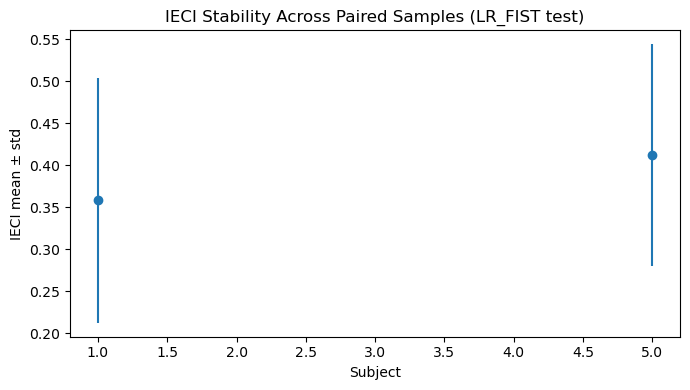

In [31]:
plt.figure(figsize=(7,4))
plt.errorbar(sum_lr["subject"], sum_lr["IECI_mean"], yerr=sum_lr["IECI_std"], fmt="o")
plt.xlabel("Subject")
plt.ylabel("IECI mean ± std")
plt.title("IECI Stability Across Paired Samples (LR_FIST test)")
plt.tight_layout()
plt.show()


## Optional: Label-wise coupling (T1 vs T2)

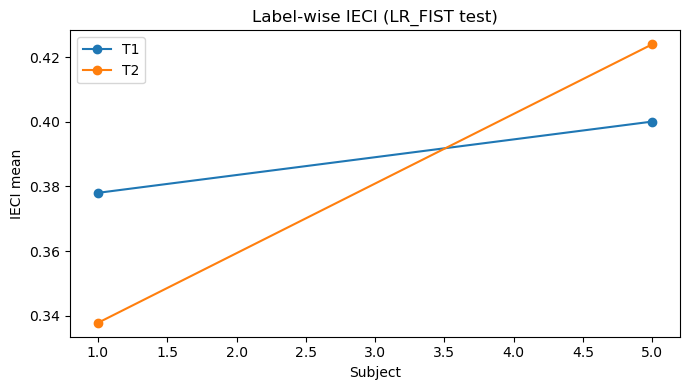

label,subject,T1,T2
0,1,0.378012,0.337790
1,5,0.400069,0.423998


In [32]:
# Pivot label-wise mean
pivot_lr = sum_lr_label.pivot(index="subject", columns="label", values="IECI_mean").reset_index()

plt.figure(figsize=(7,4))
if "T1" in pivot_lr.columns:
    plt.plot(pivot_lr["subject"], pivot_lr["T1"], marker="o", label="T1")
if "T2" in pivot_lr.columns:
    plt.plot(pivot_lr["subject"], pivot_lr["T2"], marker="o", label="T2")
plt.xlabel("Subject")
plt.ylabel("IECI mean")
plt.title("Label-wise IECI (LR_FIST test)")
plt.legend()
plt.tight_layout()
plt.show()

pivot_lr


## 11) OOD Evaluation: BF_BFET (Both fists/feet)
We compute IECI on unseen task BF_BFET using the same model (no retraining).


In [18]:
paired_ood = build_pairs(records, OOD_TASK)
print("Paired OOD_TASK samples:", len(paired_ood))

# Evaluate IECI on OOD task for the same subject split
ood_train = [d for d in paired_ood if d["subject"] in train_subj]
ood_val   = [d for d in paired_ood if d["subject"] in val_subj]
ood_test  = [d for d in paired_ood if d["subject"] in test_subj]

ieci_ood_train = compute_ieci(ood_train)
ieci_ood_val   = compute_ieci(ood_val)
ieci_ood_test  = compute_ieci(ood_test)

print("IECI OOD (test) sample:", list(ieci_ood_test.items())[:5])

# Compare within-subject: LR_FIST vs BF_BFET on test subjects
rows = []
for s in sorted(test_subj):
    rows.append({
        "subject": s,
        "IECI_LR_FIST": ieci_test.get(s, np.nan),
        "IECI_BF_BFET": ieci_ood_test.get(s, np.nan),
        "delta": (ieci_ood_test.get(s, np.nan) - ieci_test.get(s, np.nan))
    })
df_compare = pd.DataFrame(rows)
df_compare


Pairing task=BF_BFET:   0%|          | 0/10 [00:00<?, ?it/s]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=BF_BFET:  10%|█         | 1/10 [00:01<00:11,  1.23s/it]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=BF_BFET:  20%|██        | 2/10 [00:02<00:09,  1.21s/it]

...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Pairing task=BF_BFET: 100%|██████████| 10/10 [00:11<00:00,  1.15s/it]


Paired OOD_TASK samples: 442


IECI OOD (test) sample: [(1, 0.16512212694384332), (5, 0.19331056836315177)]


,subject,IECI_LR_FIST,IECI_BF_BFET,delta
0,1,0.176294,0.165122,-0.011172
1,5,0.169028,0.193311,0.024282


## 12) Save results for your paper


In [19]:
out_dir = "ieci_results_10subj"
os.makedirs(out_dir, exist_ok=True)

df_compare.to_csv(os.path.join(out_dir, "ieci_compare_test.csv"), index=False)

pd.DataFrame([{"subject":k, "IECI":v} for k,v in ieci_test.items()]).to_csv(
    os.path.join(out_dir, "ieci_lr_fist_test.csv"), index=False
)

pd.DataFrame([{"subject":k, "IECI":v} for k,v in ieci_ood_test.items()]).to_csv(
    os.path.join(out_dir, "ieci_bf_bfet_test.csv"), index=False
)

print("Saved CSVs to:", out_dir)


Saved CSVs to: ieci_results_10subj
